In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("✅ Extracted!")
print(os.listdir("/content/"))

✅ Extracted!
['.config', 'archive.zip', 'Telco_customer_churn.xlsx', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np

# Load fresh data
df = pd.read_excel("/content/Telco_customer_churn.xlsx")

print("Original Shape:", df.shape)

# Keep only these columns
keep_cols = [
    'Tenure Months', 'Monthly Charges', 'Total Charges',
    'Contract', 'Payment Method', 'Gender',
    'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Internet Service',
    'Online Security', 'Tech Support',
    'Streaming TV', 'Paperless Billing', 'Churn Value'
]
df = df[keep_cols]

# Rename target column
df = df.rename(columns={'Churn Value': 'Churn'})

# Fix Total Charges
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'], errors='coerce'
)
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median()
)

# Convert everything to numbers automatically
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)

print("✅ Cleaned Shape:", df.shape)
print("Churn column:", df['Churn'].value_counts())

Original Shape: (7043, 33)
✅ Cleaned Shape: (7043, 23)
Churn column: Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

model = RandomForestClassifier(
    n_estimators=100, random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Model Accuracy: {accuracy*100:.2f}%")
print("\nReport:")
print(classification_report(y_test, y_pred))

Training samples: 5634
Testing samples: 1409

✅ Model Accuracy: 78.42%

Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.66      0.50      0.57       400

    accuracy                           0.78      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409



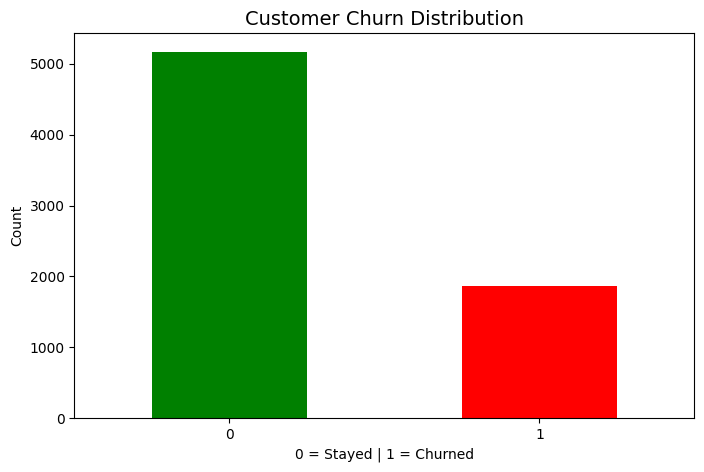

✅ Chart 1 Done!


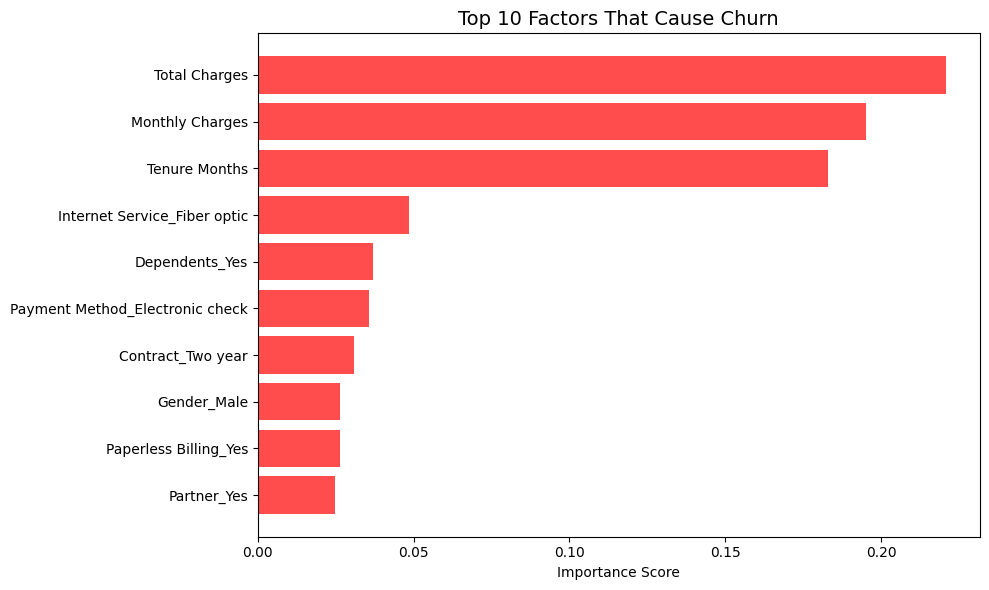

✅ Chart 2 Done!


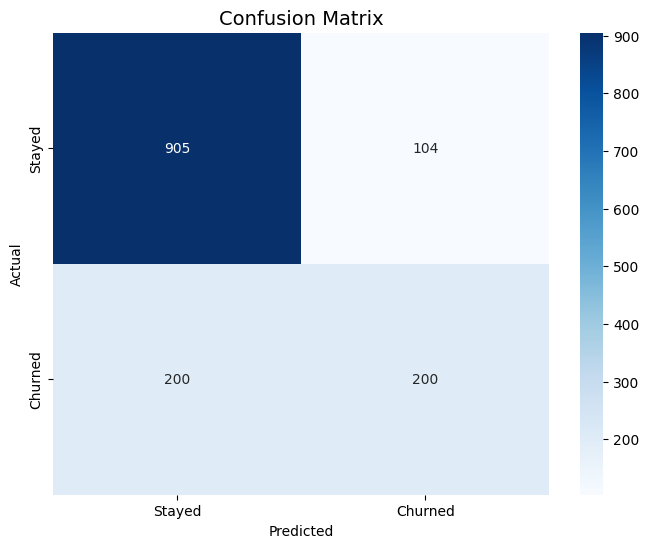

✅ Chart 3 Done!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Churn Distribution
plt.figure(figsize=(8,5))
df['Churn'].value_counts().plot(
    kind='bar', color=['green','red']
)
plt.title('Customer Churn Distribution', fontsize=14)
plt.xlabel('0 = Stayed | 1 = Churned')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('churn_distribution.png')
plt.show()
print("✅ Chart 1 Done!")

# Chart 2: Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance'],
    color='red', alpha=0.7
)
plt.title('Top 10 Factors That Cause Churn', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("✅ Chart 2 Done!")

# Chart 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Stayed','Churned'],
    yticklabels=['Stayed','Churned']
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()
print("✅ Chart 3 Done!")

In [ ]:
from google.colab import files

df.to_csv("churn_results.csv", index=False)
files.download("churn_results.csv")
files.download("churn_distribution.png")
files.download("feature_importance.png")
files.download("confusion_matrix.png")

print("✅ Project Complete! All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Project Complete! All files downloaded!


In [ ]:
!pip install imbalanced-learn xgboost

In [ ]:
from google.colab import files
uploaded = files.upload()
# Select archive.zip from your Downloads folder

Saving archive.zip to archive.zip


In [ ]:
# ============================================
# COMPLETE UPGRADED CHURN PREDICTION PROJECT
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)
from sklearn.metrics import (accuracy_score,
                             roc_auc_score,
                             roc_curve,
                             confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ---- STEP 1: Load Data ----
with zipfile.ZipFile("archive.zip", 'r') as z:
    z.extractall("/content/")

df = pd.read_excel("/content/Telco_customer_churn.xlsx")
print("✅ Data Loaded! Shape:", df.shape)

# ---- STEP 2: Clean Data ----
keep_cols = [
    'Tenure Months', 'Monthly Charges', 'Total Charges',
    'Contract', 'Payment Method', 'Gender',
    'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Internet Service',
    'Online Security', 'Tech Support',
    'Streaming TV', 'Paperless Billing', 'Churn Value'
]
df = df[keep_cols]
df = df.rename(columns={'Churn Value': 'Churn'})
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(
    df['Total Charges'].median())
df = pd.get_dummies(df, drop_first=True)
df = df.apply(pd.to_numeric, errors='coerce')
df = df.fillna(0)
print("✅ Data Cleaned! Shape:", df.shape)

# ---- STEP 3: Split Data ----
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# ---- STEP 4: Fix Imbalance with SMOTE ----
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train, y_train
)
print("\nBefore SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

# ---- STEP 5: Train 4 Models ----
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42),
    'XGBoost': XGBClassifier(
        random_state=42, eval_metric='logloss')
}

results = {}
trained_models = {}

for name, m in models.items():
    m.fit(X_train_balanced, y_train_balanced)
    pred = m.predict(X_test)
    prob = m.predict_proba(X_test)[:,1]
    results[name] = {
        'Accuracy': round(accuracy_score(
            y_test, pred)*100, 2),
        'ROC AUC': round(roc_auc_score(
            y_test, prob), 4)
    }
    trained_models[name] = m
    print(f"✅ {name} Done!")

results_df = pd.DataFrame(results).T
print("\n📊 MODEL COMPARISON:")
print(results_df)
print("\n🏆 Best Model:", results_df['ROC AUC'].idxmax())

✅ Data Loaded! Shape: (7043, 33)
✅ Data Cleaned! Shape: (7043, 23)
Training samples: 5634
Testing samples: 1409

Before SMOTE: {0: 4165, 1: 1469}
After SMOTE: {0: 4165, 1: 4165}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression Done!
✅ Random Forest Done!
✅ Gradient Boosting Done!
✅ XGBoost Done!

📊 MODEL COMPARISON:
                     Accuracy  ROC AUC
Logistic Regression     76.08   0.8248
Random Forest           77.93   0.8298
Gradient Boosting       78.71   0.8480
XGBoost                 78.35   0.8370

🏆 Best Model: Gradient Boosting


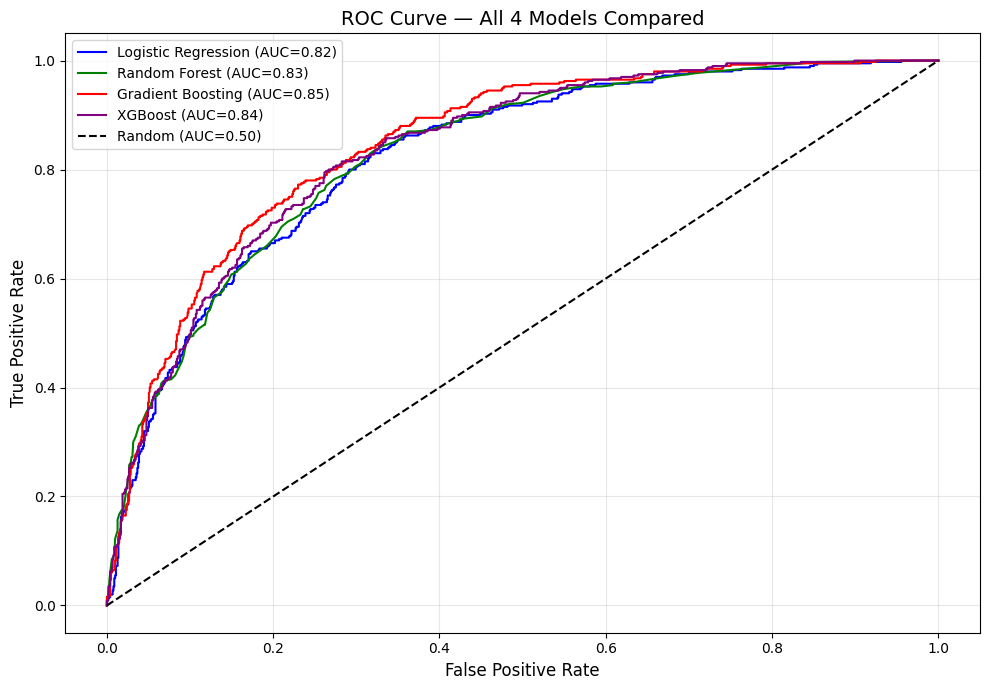

✅ ROC Curve Done!

💰 BUSINESS IMPACT
Best Model: Gradient Boosting
Correctly identified churners: 283
Revenue saved:   ₹849,000
Retention spend: ₹233,000
Net benefit:     ₹616,000
ROI:             264.4%



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ---- ROC Curve ----
plt.figure(figsize=(10,7))
colors = ['blue','green','red','purple']

for (name, m), color in zip(trained_models.items(), colors):
    prob = m.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color,
             label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All 4 Models Compared', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png')
plt.show()
print("✅ ROC Curve Done!")

# ---- Business Impact ----
best_name = results_df['ROC AUC'].idxmax()
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test)

correctly_identified = int(((y_pred_best==1) & (y_test==1)).sum())
predicted_churners = int(y_pred_best.sum())

revenue_saved = correctly_identified * 0.60 * 5000
retention_spend = predicted_churners * 500
net_benefit = revenue_saved - retention_spend
roi = (net_benefit / retention_spend) * 100

print(f"""
💰 BUSINESS IMPACT
{'='*40}
Best Model: {best_name}
Correctly identified churners: {correctly_identified}
Revenue saved:   ₹{revenue_saved:,.0f}
Retention spend: ₹{retention_spend:,.0f}
Net benefit:     ₹{net_benefit:,.0f}
ROI:             {roi:.1f}%
{'='*40}
""")

In [ ]:
from google.colab import files
files.download('roc_curve_comparison.png')
print("✅ Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!
